# 03 — Dimensionality reduction (WS3)

**Feeds C4, and decides whether the talk has an honest ≥16x measured-footprint
number at all.** WS2 closed C8 at both scales: 32x on the *codes you scan*, but
only ~3–3.5x on the *memory you provision*. Quantization alone cannot reach 16x
without trashing recall. Dimensionality reduction is the remaining multiplier —
if 1024→256 survives, 4x on the dimension times ~3.5x on the quantizer is the
first credible route to ≥16x measured.

Two ways down from 1024-d:

* **MRL truncation** — keep the first *d* coordinates, renormalize. Legitimate
  only because `mxbai-embed-large-v1` is Matryoshka-trained. We do not take the
  model card on faith; that claim is exactly what this notebook tests.
* **PCA** — project onto the top *d* principal directions of the corpus,
  renormalize. The "already committed to a non-MRL model" story, and the
  control that tells us whether MRL is doing anything special.

Crossed with the two WS2 quantizers that matter: **IVF_SQ8** (the WS2 winner)
and **IVF_RABITQ + SQ8 refine at refine_k=2** (the saturation point of the WS2
refine ablation).

**Runtime: ~9 h wall clock at 1M for the full 14-arm matrix** (estimated from
WS2's 1M per-arm timings in the cell below, printed before the run starts).
Per-arm results are cached in `data/ws3_cache/1m/`, so a crashed or
interrupted run resumes where it stopped and re-running a completed notebook
is cheap. RAM: the largest arm loads ~1.2 GiB into Milvus. Disk: ~120 GB of
`volumes/` growth across 14 ingests (Woodpecker WAL never truncates in
v2.6.18), guarded by a free-space floor.

Prereqs: notebook 01 completed at 1M; notebook 02 completed at 1M (its
`ivf_sq8` cache is the correctness gate's reference); `make up`; unit tests
green (`python -m unittest tests.test_dimensionality tests.test_quantization`).

In [1]:
# ---- setup ------------------------------------------------------------------
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd

from benchlib import manifest
from benchlib.config import *  # pinned constants — single source of truth

SCALE = "1m"          # WS3 runs at 1M; 10M is reserved for the winning combo
N_ROWS = SLICES[SCALE]
rng = np.random.default_rng(SEED)

In [2]:
# ---- Milvus connection (docker compose up -d first; `make up`) -------------
from pymilvus import MilvusClient, DataType

client = MilvusClient(uri=MILVUS_URI)
server_version = client.get_server_version()
print("Milvus server:", server_version)
assert MILVUS_VERSION in server_version, (
    f"expected pinned v{MILVUS_VERSION} — got {server_version}. "
    "Numbers from a different server version are not comparable.")

Milvus server: 2.6.18


### Methodology (locked before the run)

**1. The recall denominator is the FIXED full-dim fp64-verified ground truth
from WS1 — ground truth is never regenerated at the truncated dimension.**
This is the single most important choice in the notebook and it will be an
audience question, so state it plainly on the slide: the question WS3 asks is
*"how much of the full-dimensional relevance survives compression?"*, not
*"how self-consistent is a 256-d index with itself?"*. Re-deriving ground truth
at 256-d would answer the second question, and would score a transform that
destroys the embedding's semantics as perfect (it retrieves exactly what a
256-d brute force retrieves — by construction). A retrieval system's job is to
return what the *full-quality* model considers relevant; the full-dim GT is the
only judge that measures that. The consequence is that no truncated arm can
score 1.0, and the 1024-d controls anchor the achievable ceiling.

**2. Corpus and queries get identical treatment.** Every transform is a
row-wise function applied through the same `benchlib.dimensionality` call for corpus rows
and query rows (batch-invariance is unit-tested). Transforming only one side
would silently destroy the metric while still producing plausible-looking
numbers.

**3. MRL = truncate + L2 renormalize. PCA = center on the corpus mean +
project onto the top-*d* principal directions + L2 renormalize.** Both are an
orthonormal projection followed by renormalization, so the comparison is
apples-to-apples: the only difference is *which* d-dimensional subspace is
kept. PCA additionally re-centers, which is the standard definition (faiss
`PCAMatrix`, sklearn) and what a real deployment would ship. The rotation is
fitted on a **500k corpus-only sample** (seed 42) — never on queries, which
would leak the evaluation set into the transform — and cached with a pinned
eigenvector sign convention so its sha256 is stable and recorded in
`data/MANIFEST.json`.

**4. The 1024-d controls are the untransformed WS1 fixtures.** `mrl_1024_*`
ingests `corpus_1m_fp32_norm.npy` byte-for-byte as WS2 did, rather than
`mrl_truncate(x, 1024)`, which would renormalize already-normalized vectors and
perturb them in the last float32 ulp. The control must be comparable to WS2's
`ivf_sq8` *exactly*, because it is the correctness gate.

**5. Protocol matches the WS2 1M run, not the 10M run.** Fresh collection per
arm, no explicit compaction, `nlist=4096`, IP metric on L2-normalized vectors,
`limit=10`, recall over all 10k GT queries, latency from 100 warm-ups + 500
timed sequential single-query requests, QPS from a *separate* 8-thread run.
The 10M compact-then-freeze protocol shifts recall at fixed nprobe by up to
~1 %, which would consume the entire tie band the gate depends on. One
deliberate deviation: **the nprobe sweep extends to 512** (WS2 1M stopped at
256) because WS2 found the refine arms were still climbing at the sweep cap.

**6. Two compression axes, as in WS2.** *Payload* = nominal per-vector index
bytes vs 1024-d fp32 (4096 B). *Measured footprint* = Milvus-reported loaded
bytes (`benchlib.quantization.MEASURE_API`, taken after the query workload) vs the
**1024-d** fp32 reference — the denominator stays at full dimension for every
arm, which is the entire point of the exercise. Both the measured WS2 FLAT
load and the analytic raw-bytes figure are reported.

**7. Tie rule (from WS2's 10M noise-floor measurement): recall gaps below 0.01
are ties.** Two fresh ingests of identical data differ by up to ±0.0024 r@10;
0.01 is the conservative band applied to every cross-arm comparison here.

**8. "Single-digit recall loss" means recall@10 ≥ 0.90 against the full-dim
GT** — the same definition WS2 used, so the two notebooks' verdicts compose.

In [3]:
# ---- fixtures + preflight ---------------------------------------------------
from benchlib.quantization import (
    build_index, concurrent_qps, ensure_fresh_collection, ingest,
    latency_summary, measure_footprint, milvus_rss_bytes, payload_compression,
    pick_best_sweep_points, recall_at_k, search_ids, timed_sequential,
)
from benchlib.dimensionality import (
    fit_pca, load_pca, mrl_truncate, pca_project, sample_rows, save_pca,
    transform_corpus,
)

CACHE_DIR = DATA_DIR / "ws3_cache" / SCALE
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DERIVED_DIR = DATA_DIR / "ws3_derived"
DERIVED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_WS3 = RESULTS_DIR / "ws3"
RESULTS_WS3.mkdir(parents=True, exist_ok=True)
RESULTS_WS2 = RESULTS_DIR / "ws2"

corpus = np.load(slice_path(SCALE), mmap_mode="r")
assert corpus.shape == (N_ROWS, EMBED_DIM), corpus.shape

queries = np.load(DATA_DIR / "queries_gt_emb.npy")
assert queries.shape == (N_GT_QUERIES, EMBED_DIM), queries.shape
assert np.allclose(np.linalg.norm(queries, axis=1), 1.0, atol=1e-3)

# THE denominator: full-dim, fp64-verified, never regenerated (methodology 1)
gtz = np.load(gt_path(SCALE))
gt_indices = gtz["gt_indices"]
assert gt_indices.shape == (N_GT_QUERIES, GT_TOP_K), gt_indices.shape
assert gt_indices.max() < N_ROWS

sample = corpus[rng.choice(N_ROWS, 1000, replace=False)]
assert np.allclose(np.linalg.norm(sample, axis=1), 1.0, atol=1e-3)
del sample

print(f"fixtures OK: corpus {corpus.shape} memmap, {N_GT_QUERIES} queries, "
      f"full-dim GT top-{GT_TOP_K}; cache -> "
      f"{CACHE_DIR.relative_to(REPO_ROOT)}")

fixtures OK: corpus (1000000, 1024) memmap, 10000 queries, full-dim GT top-100; cache -> data/ws3_cache/1m


In [4]:
# ---- PCA rotations: fitted on a 500k CORPUS sample, cached + checksummed ---
# Corpus only — fitting on queries would leak the evaluation set into the
# transform. Deterministic (seed 42 sample, pinned eigenvector signs), so the
# sha256 below is a real reproducibility check, not decoration.
#
# TWO variants, because the choice turned out to matter enormously:
#   "pca"     centered   — the sklearn/faiss default, mean subtracted
#   "pca_uc"  uncentered — a truncated SVD; the projection stays an
#                          orthogonal map, so inner products survive
# Centering costs 0.17 recall@10 at 896d on this corpus (see the ceiling
# table below). Text embeddings live in a narrow cone with a large shared
# component; subtracting it and then renormalizing is a big geometric change,
# not the harmless preprocessing the default implies.
MRL_DIMS = [1024, 512, 256, 128]
REDUCED_DIMS = [512, 256, 128]
PCA_FIT_ROWS = 500_000
PCA_VARIANTS = {"pca": True, "pca_uc": False}   # name -> center?

_fit_sample = None
pca_models = {}
for _name, _center in PCA_VARIANTS.items():
    _path = DERIVED_DIR / f"pca_rotation_{SCALE}_{PCA_FIT_ROWS}_{_name}.npz"
    if not _path.exists():
        if _fit_sample is None:
            fit_idx = sample_rows(N_ROWS, PCA_FIT_ROWS, SEED)
            _fit_sample = corpus[fit_idx]          # ~2 GB fp32 in RAM
        t0 = time.time()
        print(f"fitting {_name} on {_fit_sample.shape} corpus rows "
              f"(center={_center}, seed {SEED})...")
        save_pca(fit_pca(_fit_sample, center=_center), _path)
        print(f"  fitted + saved in {time.time() - t0:.0f}s")
    pca_models[_name] = load_pca(_path)
    _digest = manifest.record(_path, {
        "kind": "ws3_pca_rotation", "fit_rows": PCA_FIT_ROWS, "seed": SEED,
        "centered": _center, "fit_source": "corpus only (never queries)",
        "scale": SCALE})
    print(f"{_name}: {pca_models[_name]['components'].shape} "
          f"centered={pca_models[_name]['centered']} sha256={_digest[:16]}…")
del _fit_sample

pca_model = pca_models["pca"]   # back-compat alias
ev = pca_models["pca_uc"]["explained_variance"]
ev_ratio = np.cumsum(ev) / ev.sum()
for d in REDUCED_DIMS:
    print(f"  cumulative explained variance (uncentered) @ {d:>4}d: "
          f"{ev_ratio[d - 1]:.4f}")


pca: (1024, 1024) centered=True sha256=a63e3a7109c3cb39…
pca_uc: (1024, 1024) centered=False sha256=57c819f6c991cc88…
  cumulative explained variance (uncentered) @  512d: 0.9833
  cumulative explained variance (uncentered) @  256d: 0.8909
  cumulative explained variance (uncentered) @  128d: 0.7591


In [5]:
# ---- materialize the transformed corpora and query sets --------------------
# One .npy per (transform, dim) for corpus and queries. The 1024d MRL control
# deliberately reuses the untransformed WS1 fixtures (methodology 4).
def arm_sources(transform: str, d: int):
    """(corpus_path, queries_path) for a (transform, dim) pair."""
    if transform == "mrl" and d == EMBED_DIM:
        return slice_path(SCALE), DATA_DIR / "queries_gt_emb.npy"
    return (DERIVED_DIR / f"corpus_{SCALE}_{transform}_{d}.npy",
            DERIVED_DIR / f"queries_{transform}_{d}.npy")


def transform_fn(transform: str, d: int):
    if transform == "mrl":
        return lambda b: mrl_truncate(b, d)
    return lambda b: pca_project(b, pca_models[transform], d)


TRANSFORM_NAMES = ("mrl", "pca", "pca_uc")

# Dims that get a full Milvus arm (the spec'd ladder, per transform).
TRANSFORMS = [(t, d) for t in TRANSFORM_NAMES for d in REDUCED_DIMS]

# Extra dims measured by the OFFLINE ceiling probe only — no Milvus arm.
# The 1024 -> 512 drop is a cliff and "somewhere between 1024 and 512" is too
# coarse an answer for C4. These rungs cost ~25 s of brute-force search each
# and locate where recall actually stops clearing the single-digit-loss line.
CEILING_EXTRA_DIMS = [896, 768, 640, 448, 384, 320]
_CEILING_DIMS = sorted(set(REDUCED_DIMS + CEILING_EXTRA_DIMS), reverse=True)
CEILING_TRANSFORMS = (
    [("mrl", EMBED_DIM),      # identity: must reproduce the WS1 GT exactly
     ("pca_uc", EMBED_DIM)]   # full-rank rotation: must ALSO be exactly 1.0
    + [(t, d) for t in TRANSFORM_NAMES for d in _CEILING_DIMS])

MATERIALIZE = sorted(
    set(TRANSFORMS)
    | {(t, d) for t in TRANSFORM_NAMES for d in CEILING_EXTRA_DIMS}
    | {("pca_uc", EMBED_DIM)})

for transform, d in MATERIALIZE:
    c_path, q_path = arm_sources(transform, d)
    fn = transform_fn(transform, d)
    if not c_path.exists():
        t0 = time.time()
        transform_corpus(corpus, c_path, fn)
        print(f"[{transform}-{d}] corpus written in {time.time() - t0:.0f}s")
        manifest.record(c_path, {"kind": "ws3_corpus", "transform": transform,
                                 "dim": d, "scale": SCALE})
    if not q_path.exists():
        np.save(q_path, fn(queries))
        manifest.record(q_path, {"kind": "ws3_queries", "transform": transform,
                                 "dim": d, "scale": SCALE})

for transform, d in CEILING_TRANSFORMS:
    c_path, q_path = arm_sources(transform, d)
    c, q = np.load(c_path, mmap_mode="r"), np.load(q_path, mmap_mode="r")
    assert c.shape == (N_ROWS, d) and q.shape == (N_GT_QUERIES, d), (c.shape, q.shape)
print(f"{len(CEILING_TRANSFORMS)} ceiling configs, "
      f"{len(MATERIALIZE)} materialized (transform, dim) pairs")


[mrl-320] corpus written in 3s


[mrl-384] corpus written in 1s


[mrl-448] corpus written in 2s


[pca-320] corpus written in 3s


[pca-384] corpus written in 3s


[pca-448] corpus written in 3s


[pca_uc-320] corpus written in 3s


[pca_uc-384] corpus written in 5s


[pca_uc-448] corpus written in 4s


29 ceiling configs, 28 materialized (transform, dim) pairs


### The offline transform ceiling — dimension loss with the quantizer removed

Before spending ~9 h of Milvus time, measure each transform's recall with
**exact brute-force search in the projected space** (no index, no quantizer),
scored against the same full-dim GT. This separates the two losses that the
Milvus arms otherwise confound: how much relevance the *projection* destroys,
versus how much the *quantizer* destroys on top of it. Without it, an MRL-256
recall drop is unattributable, and the MRL-vs-PCA verdict would be reported
through the distorting lens of whichever quantizer happened to sit on top.

The `mrl-1024` row is the identity transform, so it doubles as a check on the
probe itself: exact fp32 search over the untransformed corpus must reproduce
the WS1 fp64 ground truth to ~1.0.

In [6]:
# ---- results/ws3/transform_ceiling_1m.csv — the ONLY cell that writes it ----
import torch

PROBE_DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
PROBE_CHUNK = 200_000     # corpus rows per matmul block
PROBE_QBATCH = 2_000      # queries per matmul block


def exact_topk(q_path, c_path, k: int, chunk: int = PROBE_CHUNK,
               q_batch: int = PROBE_QBATCH) -> np.ndarray:
    """Exact top-k inner-product search in the projected space (fp32).

    Blocked on BOTH axes: the score tile is q_batch x chunk (2000 x 200k fp32
    = 1.6 GB), which is what bounds device memory — the full 10k x 1M score
    matrix would be 40 GB and would take the GPU down with it.
    """
    dev = torch.device(PROBE_DEVICE)
    src = np.load(c_path, mmap_mode="r")
    q_all = np.load(q_path)
    out = np.empty((q_all.shape[0], k), dtype=np.int64)
    for q0 in range(0, q_all.shape[0], q_batch):
        qs = torch.from_numpy(
            np.ascontiguousarray(q_all[q0:q0 + q_batch])).to(dev)
        best_v = torch.zeros((qs.shape[0], 0), device=dev)
        best_i = torch.zeros((qs.shape[0], 0), dtype=torch.int64, device=dev)
        for s in range(0, src.shape[0], chunk):
            block = torch.from_numpy(
                np.ascontiguousarray(src[s:s + chunk])).to(dev)
            scores = qs @ block.T
            v, i = torch.topk(scores, min(k, block.shape[0]), dim=1)
            best_v = torch.cat([best_v, v], dim=1)
            best_i = torch.cat([best_i, i + s], dim=1)
            v, sel = torch.topk(best_v, min(k, best_v.shape[1]), dim=1)
            best_v, best_i = v, torch.gather(best_i, 1, sel)
            del block, scores
        out[q0:q0 + q_batch] = best_i.cpu().numpy()
    return out


ceiling_path = RESULTS_WS3 / f"transform_ceiling_{SCALE}.csv"
rows = []
for transform, d in CEILING_TRANSFORMS:
    c_path, q_path = arm_sources(transform, d)
    t0 = time.time()
    pred = exact_topk(q_path, c_path, GT_TOP_K)
    r10 = recall_at_k(pred, gt_indices, 10)
    r100 = recall_at_k(pred, gt_indices, GT_TOP_K)
    rows.append(dict(scale=SCALE, transform=transform, dim=d,
                     recall_at_10=r10, recall_at_100=r100,
                     n_queries=N_GT_QUERIES, device=PROBE_DEVICE,
                     seconds=time.time() - t0))
    print(f"[ceiling] {transform}-{d:<4} r@10={r10:.4f} r@100={r100:.4f} "
          f"({time.time() - t0:.0f}s)")

ceiling = pd.DataFrame(rows)
ceiling.to_csv(ceiling_path, index=False)
print(f"wrote {ceiling_path.relative_to(REPO_ROOT)}")

# NB: bracket access — DataFrame.transform is a *method*, so
# `ceiling.transform == "mrl"` silently evaluates to False.
identity = ceiling[(ceiling["transform"] == "mrl")
                   & (ceiling["dim"] == EMBED_DIM)]
assert identity.recall_at_10.iloc[0] > 0.999, (
    "the identity probe disagrees with the WS1 ground truth — the probe, the "
    "query file, or the GT file is wrong; every ceiling number below would be "
    f"poisoned. got {identity.recall_at_10.iloc[0]}")
print("identity-probe check PASSED")
ceiling

/var/folders/n7/dx9g7skn157_pq7pvhzdpvjm0000gn/T/ipykernel_45345/3647005560.py:27: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  block = torch.from_numpy(


[ceiling] mrl-1024 r@10=1.0000 r@100=1.0000 (28s)


[ceiling] pca_uc-1024 r@10=1.0000 r@100=1.0000 (30s)


[ceiling] mrl-896  r@10=0.8714 r@100=0.8847 (27s)


[ceiling] mrl-768  r@10=0.8182 r@100=0.8318 (25s)


...

[ceiling] pca_uc-384  r@10=0.9110 r@100=0.9313 (22s)


[ceiling] pca_uc-320  r@10=0.8596 r@100=0.8876 (28s)


[ceiling] pca_uc-256  r@10=0.7892 r@100=0.8265 (27s)


[ceiling] pca_uc-128  r@10=0.5535 r@100=0.6185 (24s)
wrote results/ws3/transform_ceiling_1m.csv
identity-probe check PASSED


,scale,transform,dim,recall_at_10,recall_at_100,n_queries,device,seconds
0,1m,mrl,1024,1.00000,1.000000,10000,mps,27.952688
1,1m,pca_uc,1024,0.99997,0.999990,10000,mps,29.962889
2,1m,mrl,896,0.87143,0.884684,10000,mps,27.437752
3,1m,mrl,768,0.81816,0.831765,10000,mps,25.384425
4,1m,mrl,640,0.76223,0.777129,10000,mps,23.225012
5,1m,mrl,512,0.70035,0.715997,10000,mps,24.243068
6,1m,mrl,448,0.66279,0.678818,10000,mps,21.975063
7,1m,mrl,384,0.62414,0.640598,10000,mps,22.965423
8,1m,mrl,320,0.57487,0.593736,10000,mps,27.459875
9,1m,mrl,256,0.51881,0.538290,10000,mps,27.509762


In [7]:
# ---- the arm matrix: {mrl, pca, pca_uc} x {1024, 512, 256, 128} x quantizer
# Ordered so the protected arms land first: gate, then the MRL x SQ8 ladder,
# then the uncentered-PCA x SQ8 ladder (the only reduced-dim arms that clear
# single-digit loss), then MRL x refine, then the centered-PCA arms, and
# PCA x refine last — the first thing pruned if the run overruns its budget.
QUANTIZERS = {
    "sq8": dict(index_type="IVF_SQ8", params={"nlist": 4096},
                search_extra={}, payload_bytes=lambda d: d),
    "refine_k2": dict(index_type="IVF_RABITQ",
                      params={"nlist": 4096, "refine": True,
                              "refine_type": "SQ8"},
                      search_extra={"refine_k": 2},
                      payload_bytes=lambda d: d // 8 + d),
}
NPROBE_SWEEP = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
RECALL_TARGETS = [0.90, 0.95, 0.99]
TIE_BAND = 0.01          # WS2 10M noise floor: gaps below this are ties
SINGLE_DIGIT_LOSS = 0.90  # recall@10 floor for "single-digit recall loss"

# Uncentered PCA is the only transform whose reduced-dim arms clear
# single-digit loss, so it gets the extra rungs that bracket the 0.90
# crossing (between 512d=0.964 and 256d=0.789 on the ceiling table) plus the
# 768d ~0.99 operating point. Ordered by how much each answers the >=16x
# question. pca_uc x refine is represented at the winning dim only: the
# refine-vs-SQ8 comparison is already settled across 8 arms, and PCA x refine
# is the designated prune target.
PCA_UC_ARM_DIMS = [512, 384, 448, 768, 256, 128]

_ORDER = ([("mrl", 1024, "sq8")]
          + [("mrl", d, "sq8") for d in REDUCED_DIMS]
          + [("pca_uc", d, "sq8") for d in PCA_UC_ARM_DIMS]
          + [("mrl", 1024, "refine_k2")]
          + [("mrl", d, "refine_k2") for d in REDUCED_DIMS]
          + [("pca", d, "sq8") for d in REDUCED_DIMS]
          + [("pca_uc", 512, "refine_k2")]
          + [("pca", d, "refine_k2") for d in REDUCED_DIMS])

ARMS = {}
for transform, d, quant in _ORDER:
    q = QUANTIZERS[quant]
    c_path, q_path = arm_sources(transform, d)
    ARMS[f"{transform}_{d}_{quant}"] = dict(
        transform=transform, dim=d, quantizer=quant,
        index_type=q["index_type"], params=q["params"],
        search_extra=q["search_extra"],
        nominal_payload_bytes=q["payload_bytes"](d),
        corpus_path=c_path, queries_path=q_path)

GATE_ARM = "mrl_1024_sq8"
print(f"{len(ARMS)} arms: {list(ARMS)}")


21 arms: ['mrl_1024_sq8', 'mrl_512_sq8', 'mrl_256_sq8', 'mrl_128_sq8', 'pca_uc_512_sq8', 'pca_uc_384_sq8', 'pca_uc_448_sq8', 'pca_uc_768_sq8', 'pca_uc_256_sq8', 'pca_uc_128_sq8', 'mrl_1024_refine_k2', 'mrl_512_refine_k2', 'mrl_256_refine_k2', 'mrl_128_refine_k2', 'pca_512_sq8', 'pca_256_sq8', 'pca_128_sq8', 'pca_uc_512_refine_k2', 'pca_512_refine_k2', 'pca_256_refine_k2', 'pca_128_refine_k2']


In [8]:
# ---- wall-clock estimate (decide pruning BEFORE burning the night) ---------
# Model calibrated on the WS2 1M caches: per-arm cost = ingest + build + sweep,
# where a sweep point's cost grows with nprobe. Scaled to lower dims with a
# floor, because per-request gRPC overhead does not shrink with dimension.
import json

WS2_CACHE = DATA_DIR / "ws2_cache" / SCALE
WS2_SWEEP = [1, 2, 4, 8, 16, 32, 64, 128, 256]
_w = lambda n: 1.0 + n / 16.0
_dim_scale = lambda d: 0.25 + 0.75 * d / EMBED_DIM   # fixed overhead + O(dim)

_ws2_ref = {"sq8": "ivf_sq8", "refine_k2": "rabitq_refine_sq8_k2"}
_per_quant = {}
for quant, ws2_arm in _ws2_ref.items():
    c = json.loads((WS2_CACHE / f"{ws2_arm}.json").read_text())
    r0 = c["rows"][0]
    fixed = r0["ingest_seconds"] + r0["build_seconds"]
    sweep = c["arm_wall_seconds"] - fixed
    unit = sweep / sum(_w(n) for n in WS2_SWEEP)
    _per_quant[quant] = fixed + unit * sum(_w(n) for n in NPROBE_SWEEP)

est = pd.DataFrame([
    dict(arm=a, hours=_per_quant[s["quantizer"]] * _dim_scale(s["dim"]) / 3600)
    for a, s in ARMS.items()])
est["cumulative_h"] = est.hours.cumsum()
print(est.round(2).to_string(index=False))
print(f"\nestimated total: {est.hours.sum():.1f} h "
      f"(MRL x SQ8 ladder alone: "
      f"{est[est.arm.str.startswith('mrl') & est.arm.str.endswith('sq8')].hours.sum():.1f} h)")
print("pruning order if this overruns: PCA x refine_k2 first, never MRL x SQ8")

                 arm  hours  cumulative_h
        mrl_1024_sq8   0.73          0.73
         mrl_512_sq8   0.46          1.19
         mrl_256_sq8   0.32          1.51
         mrl_128_sq8   0.25          1.76
      pca_uc_512_sq8   0.46          2.22
      pca_uc_384_sq8   0.39          2.61
      pca_uc_448_sq8   0.42          3.03
      pca_uc_768_sq8   0.59          3.62
      pca_uc_256_sq8   0.32          3.94
      pca_uc_128_sq8   0.25          4.19
  mrl_1024_refine_k2   1.56          5.75
   mrl_512_refine_k2   0.97          6.73
   mrl_256_refine_k2   0.68          7.41
   mrl_128_refine_k2   0.54          7.95
         pca_512_sq8   0.46          8.40
         pca_256_sq8   0.32          8.72
         pca_128_sq8   0.25          8.97
pca_uc_512_refine_k2   0.97          9.95
   pca_512_refine_k2   0.97         10.92
   pca_256_refine_k2   0.68         11.61
   pca_128_refine_k2   0.54         12.14

estimated total: 12.1 h (MRL x SQ8 ladder alone: 1.8 h)
pruning order if th

In [9]:
# ---- runner: one ingest -> build -> load -> measure cycle per arm, cached ---
import shutil
import traceback

N_WARMUP, N_TIMED = 100, 500          # sequential latency run
QPS_THREADS, N_QPS_QUERIES = 8, 2000  # separate concurrent throughput run
DISK_FLOOR_GB = 50                    # Woodpecker WAL never truncates
ARM_BUDGET_S = 2 * 3600               # per-arm abort, checked between points


def free_disk_gb() -> float:
    return shutil.disk_usage(REPO_ROOT).free / 1e9


def run_arm(arm: str, spec: dict):
    """Full cycle for one arm; cached in CACHE_DIR/{arm}.json (resumable).
    Failures are recorded to {arm}.failed.json and return None — the run
    continues; parameters are never swapped silently."""
    cache_f = CACHE_DIR / f"{arm}.json"
    if cache_f.exists():
        print(f"[{arm}] cached — skipping")
        return json.loads(cache_f.read_text())
    if free_disk_gb() < DISK_FLOOR_GB:
        raise RuntimeError(
            f"free disk {free_disk_gb():.0f} GB below the {DISK_FLOOR_GB} GB "
            "floor — stopping before Milvus wedges the machine")

    dim = spec["dim"]
    vecs = np.load(spec["corpus_path"], mmap_mode="r")
    qs = np.load(spec["queries_path"])
    assert vecs.shape == (N_ROWS, dim) and qs.shape == (N_GT_QUERIES, dim)

    coll = f"ws3_{SCALE}_{arm}"
    t_arm = time.time()
    aborted = None
    try:
        ensure_fresh_collection(client, coll, dim)
        ingest_s = ingest(client, coll, vecs)
        print(f"[{arm}] ingested {N_ROWS} rows ({dim}d) in {ingest_s:.0f}s")
        build_s = build_index(client, coll, spec["index_type"], spec["params"])
        print(f"[{arm}] index built in {build_s:.0f}s")
        rss0 = milvus_rss_bytes()
        client.load_collection(coll)

        rows = []
        for nprobe in NPROBE_SWEEP:
            if time.time() - t_arm > ARM_BUDGET_S:
                aborted = (f"per-arm time budget {ARM_BUDGET_S}s exceeded "
                           f"before nprobe={nprobe}")
                print(f"[{arm}] ABORT: {aborted}")
                break
            params = {"nprobe": nprobe, **spec["search_extra"]}
            pred10 = search_ids(client, coll, qs, 10, params)
            r10 = recall_at_k(pred10, gt_indices, 10)
            pred100 = search_ids(client, coll, qs, GT_TOP_K, params)
            r100 = recall_at_k(pred100, gt_indices, GT_TOP_K)
            lat = latency_summary(timed_sequential(
                client, coll, qs, params, N_WARMUP, N_TIMED, limit=10))
            qps = concurrent_qps(client, coll, qs, params,
                                 QPS_THREADS, N_QPS_QUERIES, limit=10)
            rows.append(dict(
                scale=SCALE, arm=arm, transform=spec["transform"], dim=dim,
                quantizer=spec["quantizer"], index_type=spec["index_type"],
                sweep_param="nprobe", sweep_value=nprobe,
                refine_k=spec["search_extra"].get("refine_k"),
                recall_at_10=r10, recall_at_100=r100,
                p50_ms=lat["p50_ms"], p99_ms=lat["p99_ms"],
                qps=qps, qps_threads=QPS_THREADS,
                build_seconds=build_s, ingest_seconds=ingest_s,
                nominal_payload_bytes=spec["nominal_payload_bytes"],
                n_rows=N_ROWS, n_recall_queries=N_GT_QUERIES))
            print(f"[{arm}] nprobe={nprobe}: r@10={r10:.4f} r@100={r100:.4f} "
                  f"p50={lat['p50_ms']:.2f}ms qps={qps:.0f}")

        # footprint AFTER the workload — v2.6 materializes serving state lazily
        m = measure_footprint(client, coll, rss0)
        for row in rows:
            row.update({k: m[k] for k in (
                "loaded_bytes", "index_files_bytes", "chunk_cache_bytes",
                "segment_heap_bytes")})
        result = {"arm": arm, "rows": rows, "measure": m, "aborted": aborted,
                  "arm_wall_seconds": time.time() - t_arm,
                  "free_disk_gb_after": free_disk_gb()}
        cache_f.write_text(json.dumps(result, indent=1))
        print(f"[{arm}] done in {result['arm_wall_seconds']:.0f}s; loaded "
              f"{m['loaded_bytes'] / 2**20:.0f} MiB; "
              f"{result['free_disk_gb_after']:.0f} GB disk free")
        return result
    except Exception as e:
        (CACHE_DIR / f"{arm}.failed.json").write_text(json.dumps(
            {"arm": arm, "error": repr(e),
             "traceback": traceback.format_exc()}, indent=1))
        print(f"[{arm}] FAILED — recorded, continuing: {e!r}")
        return None
    finally:
        try:
            client.release_collection(coll)
            client.drop_collection(coll)
        except Exception:
            pass

### Correctness gate — the 1024-d SQ8 control must reproduce WS2

`mrl_1024_sq8` ingests the identical fixture, at the identical dimension, with
the identical index parameters as WS2's `ivf_sq8` arm at 1M. If the WS3 harness
is sound it must reproduce that curve at every shared nprobe, within the WS2
noise floor. A disagreement means the transform plumbing, the query file, or
the collection setup is wrong — and every dimension-reduction number in this
notebook would be measuring the bug rather than the transform. So this raises.

In [10]:
# ---- correctness gate: WS3 1024d SQ8 control vs the WS2 1M ivf_sq8 curve ----
gate = run_arm(GATE_ARM, ARMS[GATE_ARM])
if gate is None:
    raise RuntimeError(f"gate arm {GATE_ARM} failed — cannot proceed. "
                       f"See {CACHE_DIR}/{GATE_ARM}.failed.json")

ws2_sq8 = json.loads((WS2_CACHE / "ivf_sq8.json").read_text())
ws2_by_nprobe = {r["sweep_value"]: r["recall_at_10"] for r in ws2_sq8["rows"]}
cmp_rows = [
    dict(nprobe=r["sweep_value"], ws3=r["recall_at_10"],
         ws2=ws2_by_nprobe[r["sweep_value"]],
         delta=r["recall_at_10"] - ws2_by_nprobe[r["sweep_value"]])
    for r in gate["rows"] if r["sweep_value"] in ws2_by_nprobe]
gate_cmp = pd.DataFrame(cmp_rows)
worst = gate_cmp.delta.abs().max()
print(gate_cmp.round(5).to_string(index=False))
print(f"\nworst |delta recall@10| = {worst:.5f} (tie band {TIE_BAND})")
if worst >= TIE_BAND:
    raise RuntimeError(
        f"CORRECTNESS GATE FAILED: the 1024d SQ8 control does not reproduce "
        f"the WS2 1M ivf_sq8 curve (worst delta {worst:.5f} >= {TIE_BAND}). "
        "Debug the harness before trusting any dimensionality result — "
        "suspect the query file, insert order/PK mapping, or index params.")
print("gate PASSED — the WS3 harness reproduces WS2; proceeding to the matrix")

[mrl_1024_sq8] cached — skipping
 nprobe     ws3     ws2    delta
      1 0.55060 0.55032  0.00028
      2 0.69240 0.69425 -0.00185
      4 0.80827 0.80756  0.00071
      8 0.88955 0.88814  0.00141
     16 0.93181 0.93782 -0.00601
     32 0.96276 0.96105  0.00171
     64 0.98011 0.97755  0.00256
    128 0.98597 0.98468  0.00129
    256 0.99105 0.99031  0.00074

worst |delta recall@10| = 0.00601 (tie band 0.01)
gate PASSED — the WS3 harness reproduces WS2; proceeding to the matrix


In [11]:
# ---- run the matrix (each arm cached; ~9 h at 1M) --------------------------
t_matrix = time.time()
for arm, spec in ARMS.items():
    if arm == GATE_ARM:
        continue  # the gate cell above already ran it
    run_arm(arm, spec)
print(f"matrix wall clock this session: {time.time() - t_matrix:.0f}s")

failed = sorted(p.name.replace(".failed.json", "")
                for p in CACHE_DIR.glob("*.failed.json"))
done = sorted(p.stem for p in CACHE_DIR.glob("*.json")
              if not p.name.endswith(".failed.json"))
print(f"arms complete: {len(done)}/{len(ARMS)}: {done}")
if failed:
    print(f"arms FAILED (recorded, see cache dir): {failed}")

[mrl_512_sq8] cached — skipping
[mrl_256_sq8] cached — skipping
[mrl_128_sq8] cached — skipping


[pca_uc_512_sq8] ingested 1000000 rows (512d) in 152s


[pca_uc_512_sq8] index built in 156s


I0816 20:45:44.142510 10493159 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(90, generation: 1)


[pca_uc_512_sq8] nprobe=1: r@10=0.4851 r@100=0.3690 p50=3.80ms qps=440


...

I0816 23:42:36.648787 10866328 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(90, generation: 1)


I0816 23:42:37.778728 10866388 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(90, generation: 1)
I0816 23:42:37.903326 10866432 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(90, generation: 1)


I0816 23:42:38.040765 10866518 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(90, generation: 1)


[pca_uc_512_refine_k2] done in 4450s; loaded 670 MiB; 284 GB disk free


[pca_512_refine_k2] cached — skipping
[pca_256_refine_k2] cached — skipping
[pca_128_refine_k2] cached — skipping
matrix wall clock this session: 10926s
arms complete: 21/21: ['mrl_1024_refine_k2', 'mrl_1024_sq8', 'mrl_128_refine_k2', 'mrl_128_sq8', 'mrl_256_refine_k2', 'mrl_256_sq8', 'mrl_512_refine_k2', 'mrl_512_sq8', 'pca_128_refine_k2', 'pca_128_sq8', 'pca_256_refine_k2', 'pca_256_sq8', 'pca_512_refine_k2', 'pca_512_sq8', 'pca_uc_128_sq8', 'pca_uc_256_sq8', 'pca_uc_384_sq8', 'pca_uc_448_sq8', 'pca_uc_512_refine_k2', 'pca_uc_512_sq8', 'pca_uc_768_sq8']


In [12]:
# ---- results/ws3/curves_1m.csv — the ONLY cell that writes it --------------
# Footprint denominator stays at 1024d for every arm (methodology 6): the
# measured WS2 FLAT load is the primary reference so WS3 points overlay
# directly on the WS2 chart; the analytic raw-bytes figure is carried too.
ws2_curves = pd.read_csv(RESULTS_WS2 / f"curves_{SCALE}.csv")
FLAT_1024_LOADED = int(
    ws2_curves.loc[ws2_curves.arm == "flat_fp32", "loaded_bytes"].iloc[0])
RAW_1024_BYTES = N_ROWS * EMBED_DIM * 4

all_rows = []
for arm in ARMS:  # matrix order, not glob order
    cache_f = CACHE_DIR / f"{arm}.json"
    if cache_f.exists():
        all_rows.extend(json.loads(cache_f.read_text())["rows"])

curves = pd.DataFrame(all_rows)
curves["payload_compression_vs_1024_fp32"] = (
    4 * EMBED_DIM / curves.nominal_payload_bytes)
curves["footprint_compression_vs_flat_1024"] = (
    FLAT_1024_LOADED / curves.loaded_bytes)
curves["footprint_compression_vs_raw_1024"] = (
    RAW_1024_BYTES / curves.loaded_bytes)
curves["dim_compression"] = EMBED_DIM / curves.dim

curves_path = RESULTS_WS3 / f"curves_{SCALE}.csv"
curves.to_csv(curves_path, index=False)
print(f"wrote {curves_path.relative_to(REPO_ROOT)}: {len(curves)} rows, "
      f"{curves.arm.nunique()} arms")
print(f"denominators: measured FLAT-1024 {FLAT_1024_LOADED / 2**20:.0f} MiB, "
      f"analytic raw-1024 {RAW_1024_BYTES / 2**20:.0f} MiB")
curves.groupby("arm", sort=False).agg(
    points=("sweep_value", "size"), best_r10=("recall_at_10", "max"),
    loaded_MiB=("loaded_bytes", lambda b: b.iloc[0] / 2**20),
    footprint_x=("footprint_compression_vs_flat_1024", "first")).round(3)

wrote results/ws3/curves_1m.csv: 210 rows, 21 arms
denominators: measured FLAT-1024 3960 MiB, analytic raw-1024 3906 MiB


,points,best_r10,loaded_MiB,footprint_x
arm,,,,
mrl_1024_sq8,10,0.991,1123.660,3.525
mrl_512_sq8,10,0.700,586.836,6.749
mrl_256_sq8,10,0.517,318.133,12.449
mrl_128_sq8,10,0.331,193.113,20.508
pca_uc_512_sq8,10,0.960,590.551,6.706
pca_uc_384_sq8,10,0.909,457.340,8.660
pca_uc_448_sq8,10,0.939,510.344,7.760
pca_uc_768_sq8,10,0.982,841.816,4.705
pca_uc_256_sq8,10,0.788,316.180,12.526


In [13]:
# ---- results/ws3/dim_verdict_1m.csv — the ONLY cell that writes it ---------
# One row per arm (= dim x quantizer x transform): best recall reached, the
# measured footprint against the 1024d denominator, and whether the arm holds
# single-digit recall loss against the full-dim GT. This is the table the
# >=16x question is answered from.
ceiling_lookup = {(r.transform, r.dim): r.recall_at_10
                  for r in ceiling.itertuples()}

rows = []
for arm, spec in ARMS.items():
    g = curves[curves.arm == arm]
    if not len(g):
        continue
    best = g.loc[g.recall_at_10.idxmax()]
    # bracket access: DataFrame.transform is a method, not this column
    ctrl = curves[(curves["transform"] == "mrl")
                  & (curves["dim"] == EMBED_DIM)
                  & (curves["quantizer"] == spec["quantizer"])]
    ctrl_best = ctrl.recall_at_10.max() if len(ctrl) else np.nan
    at_95 = g[g.recall_at_10 >= 0.95]
    rows.append(dict(
        arm=arm, transform=spec["transform"], dim=spec["dim"],
        quantizer=spec["quantizer"],
        best_recall_at_10=best.recall_at_10,
        best_recall_at_100=best.recall_at_100,
        at_nprobe=int(best.sweep_value),
        recall_loss_vs_full_dim_gt=1.0 - best.recall_at_10,
        recall_loss_vs_1024_control=ctrl_best - best.recall_at_10,
        exact_search_ceiling_at_10=ceiling_lookup.get(
            (spec["transform"], spec["dim"]), np.nan),
        quantizer_loss_below_ceiling=(
            ceiling_lookup.get((spec["transform"], spec["dim"]), np.nan)
            - best.recall_at_10),
        single_digit_loss=bool(best.recall_at_10 >= SINGLE_DIGIT_LOSS),
        loaded_MiB=best.loaded_bytes / 2**20,
        footprint_compression_vs_flat_1024=best.footprint_compression_vs_flat_1024,
        footprint_compression_vs_raw_1024=best.footprint_compression_vs_raw_1024,
        payload_compression_vs_1024_fp32=best.payload_compression_vs_1024_fp32,
        dim_compression=best.dim_compression,
        p50_ms_at_best=best.p50_ms, qps_at_best=best.qps,
        nprobe_for_0p95=int(at_95.sweep_value.min()) if len(at_95) else None,
        qps_at_0p95=at_95.qps.max() if len(at_95) else None,
        segment_heap_MiB=best.segment_heap_bytes / 2**20,
        index_files_MiB=best.index_files_bytes / 2**20,
        n_rows=int(best.n_rows), scale=SCALE))

verdict = pd.DataFrame(rows).sort_values(
    "footprint_compression_vs_flat_1024", ascending=False).reset_index(drop=True)
verdict_path = RESULTS_WS3 / f"dim_verdict_{SCALE}.csv"
verdict.to_csv(verdict_path, index=False)
print(f"wrote {verdict_path.relative_to(REPO_ROOT)}")

with pd.option_context("display.width", 200, "display.max_columns", 30):
    print(verdict[["arm", "best_recall_at_10", "exact_search_ceiling_at_10",
                   "quantizer_loss_below_ceiling", "single_digit_loss",
                   "loaded_MiB", "footprint_compression_vs_flat_1024",
                   "qps_at_best"]].round(4).to_string())

wrote results/ws3/dim_verdict_1m.csv
                     arm  best_recall_at_10  exact_search_ceiling_at_10  quantizer_loss_below_ceiling  single_digit_loss  loaded_MiB  footprint_compression_vs_flat_1024  qps_at_best
0         pca_uc_128_sq8             0.5534                      0.5535                        0.0002              False    189.1679                             20.9357     256.0311
1            mrl_128_sq8             0.3310                      0.3323                        0.0013              False    193.1132                             20.5080     419.4055
2            pca_128_sq8             0.5495                      0.5500                        0.0005              False    193.2499                             20.4935     502.6339
3      mrl_128_refine_k2             0.3092                      0.3323                        0.0231              False    212.6991                             18.6196     724.6443
4      pca_128_refine_k2             0.5324          

wrote results/ws3/chart_recall_vs_compression_1m.png


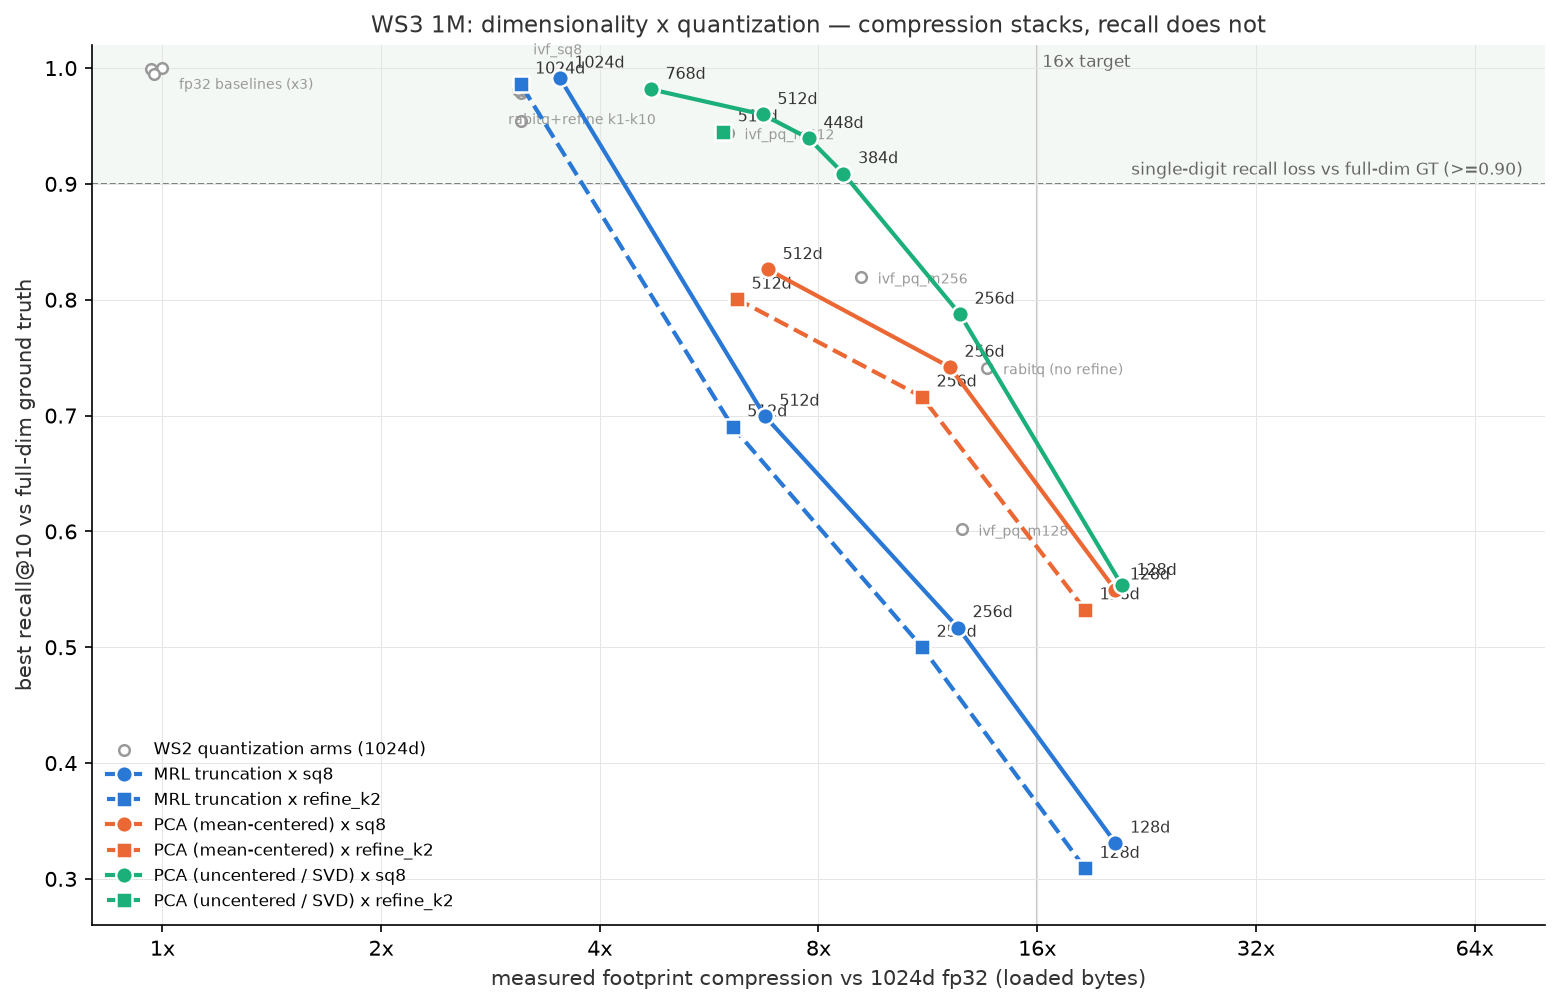

In [14]:
# ---- chart: recall vs measured footprint compression, WS2 arms overlaid ----
# Three categorical hues (validated: worst CVD dE 9.2 deutan, normal-vision
# dE 27.6). The green sits just under 3:1 contrast, which the skill says
# obligates relief rather than dismissal — every point carries a direct dim
# label, there is a legend, and dim_verdict_1m.csv is the table view.
# Quantizer is encoded by line style and transform by marker shape, so
# identity never rests on colour alone.
import matplotlib.pyplot as plt

TRANSFORM_COLOR = {"mrl": "#2a78d6", "pca": "#eb6834", "pca_uc": "#1baf7a"}
TRANSFORM_LABEL = {"mrl": "MRL truncation", "pca": "PCA (mean-centered)",
                   "pca_uc": "PCA (uncentered / SVD)"}
QUANT_STYLE = {"sq8": ("-", "o"), "refine_k2": ("--", "s")}
INK, INK2, GRID, REF = "#333333", "#666666", "#e5e5e5", "#999999"

# One label per WS2 *family*: flat/hnsw/ivf_flat all sit on top of each other
# at ~1x, and the four refine arms are indistinguishable at ~3.1x. Labelling
# each one produces an unreadable pile, so near-duplicates go unlabelled.
WS2_LABEL = {
    "flat_fp32": "fp32 baselines (x3)", "ivf_sq8": "ivf_sq8",
    "ivf_pq_m512": "ivf_pq_m512", "ivf_pq_m256": "ivf_pq_m256",
    "ivf_pq_m128": "ivf_pq_m128", "rabitq": "rabitq (no refine)",
    "rabitq_refine_sq8_k2": "rabitq+refine k1-k10",
}
WS2_OFFSET = {"flat_fp32": (8, -10), "ivf_sq8": (-12, 12),
              "rabitq_refine_sq8_k2": (-6, -15), "ivf_pq_m512": (8, -3),
              "ivf_pq_m256": (8, -3), "ivf_pq_m128": (8, -3),
              "rabitq": (8, -3)}

fig, ax = plt.subplots(figsize=(10.5, 6.8), dpi=150)
ax.axhspan(SINGLE_DIGIT_LOSS, 1.02, color="#f4f8f4", zorder=0)
ax.axhline(SINGLE_DIGIT_LOSS, color=INK2, lw=0.8, ls="--", zorder=1)
ax.text(0.985, SINGLE_DIGIT_LOSS + 0.008,
        "single-digit recall loss vs full-dim GT (>=0.90)", ha="right",
        color=INK2, fontsize=8, transform=ax.get_yaxis_transform())
ax.axvline(16, color="#c8c8c8", lw=1.0, zorder=1)
ax.text(16, 1.012, " 16x target", ha="left", va="top", color=INK2, fontsize=8)

# reference layer: WS2's 1M arms, best point each (neutral, direct-labelled)
ws2_best = (ws2_curves.groupby("arm", sort=False)
            .apply(lambda g: g.loc[g.recall_at_10.idxmax()],
                   include_groups=False).reset_index())
ax.scatter(ws2_best.footprint_compression_vs_flat, ws2_best.recall_at_10,
           s=26, facecolor="white", edgecolor=REF, lw=1.2, zorder=3,
           label="WS2 quantization arms (1024d)")
for _, r in ws2_best.iterrows():
    if r.arm in WS2_LABEL:
        ax.annotate(WS2_LABEL[r.arm],
                    (r.footprint_compression_vs_flat, r.recall_at_10),
                    textcoords="offset points",
                    xytext=WS2_OFFSET.get(r.arm, (8, -3)), fontsize=6.5,
                    color=REF)

# WS3: one line per (transform, quantizer), walking the dimension ladder
for transform in ("mrl", "pca", "pca_uc"):
    for quant in ("sq8", "refine_k2"):
        # bracket access: DataFrame.transform is a method
        g = verdict[(verdict["transform"] == transform)
                    & (verdict["quantizer"] == quant)].sort_values("dim")
        if not len(g):
            continue
        ls, marker = QUANT_STYLE[quant]
        c = TRANSFORM_COLOR[transform]
        ax.plot(g.footprint_compression_vs_flat_1024, g.best_recall_at_10,
                ls=ls, marker=marker, color=c, lw=2, ms=8, zorder=4,
                markeredgecolor="white", markeredgewidth=1.2,
                label=f"{TRANSFORM_LABEL[transform]} x {quant}")
        for _, r in g.iterrows():
            ax.annotate(f"{int(r.dim)}d",
                        (r.footprint_compression_vs_flat_1024,
                         r.best_recall_at_10),
                        textcoords="offset points", xytext=(7, 5),
                        fontsize=7.5, color=INK)

ax.set_xscale("log", base=2)
ax.set_xlim(0.8, 80)
ax.set_xticks([1, 2, 4, 8, 16, 32, 64])
ax.set_xticklabels(["1x", "2x", "4x", "8x", "16x", "32x", "64x"])
# floor below the worst arm (mrl_128_refine_k2 = 0.309) — an axis that clips
# the weakest points would flatter the transforms exactly where they fail
ax.set_ylim(0.26, 1.02)
ax.set_xlabel("measured footprint compression vs 1024d fp32 (loaded bytes)",
              color=INK)
ax.set_ylabel("best recall@10 vs full-dim ground truth", color=INK)
ax.set_title(f"WS3 {SCALE.upper()}: dimensionality x quantization — "
             "compression stacks, recall does not", color=INK, fontsize=11)
ax.grid(True, color=GRID, lw=0.5, zorder=0)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()
chart_path = RESULTS_WS3 / f"chart_recall_vs_compression_{SCALE}.png"
fig.savefig(chart_path, bbox_inches="tight")
print(f"wrote {chart_path.relative_to(REPO_ROOT)}")
plt.show()


In [15]:
# ---- verdict summary (the two paragraphs in results/index-footprint.md come from here) --
print("=" * 78)
print("VERDICT 1 — MRL vs PCA: is mxbai's Matryoshka claim real on recall?")
print("=" * 78)
mv = ceiling.pivot_table(index="dim", columns="transform", values="recall_at_10")
if "pca" in mv and "mrl" in mv:
    mv["mrl_minus_pca"] = mv["mrl"] - mv["pca"]
    mv["tie"] = mv.mrl_minus_pca.abs() < TIE_BAND
print("exact-search ceiling (no quantizer), recall@10 vs full-dim GT:")
print(mv.round(4).to_string())

print("\nwith the quantizer on top (best point per arm):")
print(verdict.pivot_table(index=["dim", "quantizer"], columns="transform",
                          values="best_recall_at_10").round(4).to_string())

print("\n" + "=" * 78)
print("VERDICT 2 — the >=16x question")
print("=" * 78)
ok = verdict[verdict.single_digit_loss].sort_values(
    "footprint_compression_vs_flat_1024", ascending=False)
if len(ok):
    b = ok.iloc[0]
    print(f"best single-digit-loss point: {b.arm}")
    print(f"  recall@10                 {b.best_recall_at_10:.4f} "
          f"(loss {b.recall_loss_vs_full_dim_gt:.4f} vs full-dim GT)")
    print(f"  measured footprint        "
          f"{b.footprint_compression_vs_flat_1024:.2f}x vs measured FLAT-1024 "
          f"/ {b.footprint_compression_vs_raw_1024:.2f}x vs analytic raw")
    print(f"  loaded                    {b.loaded_MiB:.0f} MiB "
          f"(of which {b.segment_heap_MiB:.0f} MiB dim-independent heap)")
    print(f"  payload (nominal)         "
          f"{b.payload_compression_vs_1024_fp32:.1f}x")
    print(f"  at nprobe={int(b.at_nprobe)}  p50 {b.p50_ms_at_best:.1f} ms, "
          f"{b.qps_at_best:.0f} QPS (8 threads)")
    print(f"\n  >=16x measured with single-digit loss: "
          f"{'YES' if b.footprint_compression_vs_flat_1024 >= 16 else 'NO'}")
else:
    print("NO arm holds single-digit recall loss — report the ceiling honestly")

print("\nall arms above 8x measured footprint:")
print(verdict[verdict.footprint_compression_vs_flat_1024 >= 8][
    ["arm", "best_recall_at_10", "footprint_compression_vs_flat_1024",
     "single_digit_loss"]].round(4).to_string(index=False))

VERDICT 1 — MRL vs PCA: is mxbai's Matryoshka claim real on recall?
exact-search ceiling (no quantizer), recall@10 vs full-dim GT:
transform     mrl     pca  pca_uc  mrl_minus_pca    tie
dim                                                    
128        0.3323  0.5500  0.5535        -0.2177  False
256        0.5188  0.7434  0.7892        -0.2246  False
320        0.5749  0.7876  0.8596        -0.2127  False
384        0.6241  0.8135  0.9110        -0.1894  False
448        0.6628  0.8238  0.9443        -0.1610  False
512        0.7004  0.8271  0.9637        -0.1267  False
640        0.7622  0.8299  0.9826        -0.0677  False
768        0.8182  0.8308  0.9909        -0.0126  False
896        0.8714  0.8312  0.9956         0.0402  False
1024       1.0000     NaN  1.0000            NaN  False

with the quantizer on top (best point per arm):
transform          mrl     pca  pca_uc
dim  quantizer                        
128  refine_k2  0.3092  0.5324     NaN
     sq8        0.3310  0.5495 